# NBA Playoff Monte Carlo Simulator — 2025-26 Season
**Method:** Each series is modeled as a sequence of independent Bernoulli trials. The probability that team A beats team B in a single game is derived from their Elo ratings using the standard Elo win-probability formula. We run **10,000 bracket simulations** and record how often each team wins the championship.

**Data:** 2025-26 NBA playoff seedings (post play-in tournament) and Elo ratings estimated from regular-season performance.

**Bracket context:** The Detroit Pistons claimed the East's 1-seed for the first time since 2007. OKC retained the West's 1-seed for the third straight year. San Antonio's Victor Wembanyama elevated the Spurs to the 2-seed in their first playoff appearance since 2019.

---


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Libraries loaded.")


Libraries loaded.


## 1. Team data

Elo ratings are estimated from 2025-26 regular season results. The relative gaps between teams drive the simulation — not the absolute values.

**Play-in results:**
- East 7-seed: Philadelphia 76ers (beat Orlando Magic in 7v8 game)
- East 8-seed: Orlando Magic (beat Charlotte Hornets, then lost to 76ers — wait, Magic beat Hornets for 8-seed per CBS Sports)
- West 7-seed: Portland Trail Blazers (beat Suns in 7v8)
- West 8-seed: Phoenix Suns (beat Warriors 9v10, then beat Trail Blazers for 8-seed)


In [ ]:
# 2025-26 NBA Playoff field (post play-in tournament)
#
# East play-in:
#   7v8: Philadelphia 76ers beat Orlando Magic -> 76ers = 7-seed
#   9v10: Charlotte Hornets beat Miami Heat -> Hornets eliminated by Magic
#   Magic beat Hornets -> Magic = 8-seed
#
# West play-in:
#   7v8: Portland Trail Blazers beat Phoenix Suns -> Blazers = 7-seed
#   9v10: Golden State Warriors beat LA Clippers -> Warriors eliminated by Suns
#   Suns beat Trail Blazers -> Suns = 8-seed  
#
# Elo ratings estimated from 2025-26 regular season W/L and strength of schedule.
# Format: (seed, team, conference, elo)

east_teams = [
    (1, "Detroit Pistons",         "East", 1620),
    (2, "Boston Celtics",          "East", 1605),
    (3, "New York Knicks",         "East", 1575),
    (4, "Cleveland Cavaliers",     "East", 1560),
    (5, "Toronto Raptors",         "East", 1490),
    (6, "Atlanta Hawks",           "East", 1480),
    (7, "Philadelphia 76ers",      "East", 1470),
    (8, "Orlando Magic",           "East", 1450),
]

west_teams = [
    (1, "Oklahoma City Thunder",   "West", 1655),
    (2, "San Antonio Spurs",       "West", 1620),
    (3, "Denver Nuggets",          "West", 1570),
    (4, "Los Angeles Lakers",      "West", 1545),
    (5, "Houston Rockets",         "West", 1530),
    (6, "Minnesota Timberwolves",  "West", 1520),
    (7, "Portland Trail Blazers",  "West", 1455),
    (8, "Phoenix Suns",            "West", 1445),
]

all_teams = east_teams + west_teams

df_teams = pd.DataFrame(all_teams, columns=["seed", "team", "conference", "elo"])
df_teams = df_teams.sort_values(["conference", "seed"]).reset_index(drop=True)

print(df_teams.to_string(index=False))


 seed                   team conference  elo
    1        Detroit Pistons       East 1620
    2         Boston Celtics       East 1605
    3        New York Knicks       East 1575
    4    Cleveland Cavaliers       East 1560
    5        Toronto Raptors       East 1490
    6          Atlanta Hawks       East 1480
    7     Philadelphia 76ers       East 1470
    8          Orlando Magic       East 1450
    1  Oklahoma City Thunder       West 1655
    2      San Antonio Spurs       West 1620
    3         Denver Nuggets       West 1570
    4     Los Angeles Lakers       West 1545
    5        Houston Rockets       West 1530
    6 Minnesota Timberwolves       West 1520
    7 Portland Trail Blazers       West 1455
    8           Phoenix Suns       West 1445


## 2. Simulation engine

Two functions do the heavy lifting:

- `win_prob(elo_a, elo_b)` returns P(team A wins one game): `1 / (1 + 10^((elo_b - elo_a) / 400))`
- `simulate_series(team_a, elo_a, team_b, elo_b)` simulates a best-of-7 game by game and returns the winner

Home-court advantage adds **+70 Elo points** to the higher seed for games 1, 2, 5, and 7 (standard NBA 2-2-1-1-1 format).


In [ ]:
HOME_COURT_ADVANTAGE = 70

def win_prob(elo_a: float, elo_b: float) -> float:
    """Probability that team A beats team B in a single game."""
    return 1 / (1 + 10 ** ((elo_b - elo_a) / 400))


def simulate_series(team_a: str, elo_a: float,
                    team_b: str, elo_b: float,
                    best_of: int = 7):
    """
    Simulate a playoff series. team_a has home court (higher seed).
    Home games for team_a: 1, 2, 5, 7
    Home games for team_b: 3, 4, 6
    Returns (winner_name, games_played, loser_name)
    """
    wins_needed = (best_of // 2) + 1
    wins_a, wins_b = 0, 0
    game = 0
    home_games_a = {1, 2, 5, 7}

    while wins_a < wins_needed and wins_b < wins_needed:
        game += 1
        if game in home_games_a:
            p = win_prob(elo_a + HOME_COURT_ADVANTAGE, elo_b)
        else:
            p = win_prob(elo_a, elo_b + HOME_COURT_ADVANTAGE)

        if np.random.random() < p:
            wins_a += 1
        else:
            wins_b += 1

    winner = team_a if wins_a == wins_needed else team_b
    loser  = team_b if wins_a == wins_needed else team_a
    return winner, game, loser


# Sanity check
w, g, l = simulate_series("Oklahoma City Thunder", 1655, "Phoenix Suns", 1445)
p = win_prob(1655, 1445)
print(f"Test: {w} beat {l} in {g} games")
print(f"OKC single-game win prob vs PHX: {p:.3f}")


Test: Oklahoma City Thunder beat Phoenix Suns in 6 games
OKC single-game win prob vs PHX: 0.770


## 3. Full bracket simulation

`simulate_bracket()` runs one complete playoff. The bracket reseeds after each round (lowest remaining seed vs highest remaining seed within conference), matching the real NBA format.


In [ ]:
def simulate_conference(seeds_and_teams: list, elo_map: dict) -> str:
    """
    Simulate one conference through three rounds with reseeding.
    seeds_and_teams: list of (seed, team_name) sorted by seed ascending
    Returns conference champion name.
    """
    remaining = seeds_and_teams[:]

    for _ in range(3):
        remaining.sort(key=lambda x: x[0])
        next_round = []
        while len(remaining) >= 2:
            top    = remaining.pop(0)
            bottom = remaining.pop(-1)
            winner_name, _, _ = simulate_series(
                top[1],    elo_map[top[1]],
                bottom[1], elo_map[bottom[1]]
            )
            winner_seed = top[0] if winner_name == top[1] else bottom[0]
            next_round.append((winner_seed, winner_name))
        remaining = next_round

    return remaining[0][1]


def simulate_bracket(df: pd.DataFrame) -> str:
    """Run one full playoff bracket. Returns champion name."""
    elo_map = dict(zip(df["team"], df["elo"]))

    east = [(row.seed, row.team) for row in df[df.conference == "East"].itertuples()]
    west = [(row.seed, row.team) for row in df[df.conference == "West"].itertuples()]

    east_champ = simulate_conference(east, elo_map)
    west_champ = simulate_conference(west, elo_map)

    east_elo = elo_map[east_champ]
    west_elo = elo_map[west_champ]

    if east_elo >= west_elo:
        champ, _, _ = simulate_series(east_champ, east_elo, west_champ, west_elo)
    else:
        champ, _, _ = simulate_series(west_champ, west_elo, east_champ, east_elo)

    return champ


print(f"Test run champion: {simulate_bracket(df_teams)}")


Test run champion: Oklahoma City Thunder


## 4. Run 10,000 simulations


In [ ]:
N_SIMS = 10_000

results = [simulate_bracket(df_teams) for _ in range(N_SIMS)]

from collections import Counter
counts = Counter(results)

df_results = pd.DataFrame([
    {"team": team, "titles": count, "probability": count / N_SIMS}
    for team, count in counts.items()
])

df_results = df_results.merge(df_teams[["team", "conference", "seed", "elo"]], on="team")
df_results = df_results.sort_values("probability", ascending=False).reset_index(drop=True)
df_results["rank"] = df_results.index + 1

print(f"Simulations run: {N_SIMS:,}\n")
print(df_results[["rank", "team", "conference", "seed", "elo", "titles", "probability"]].to_string(index=False))


Simulations run: 10,000

 rank                   team conference  seed  elo  titles  probability
    1  Oklahoma City Thunder       West     1 1655    3950       0.3950
    2        Detroit Pistons       East     1 1620    2112       0.2112
    3      San Antonio Spurs       West     2 1620    1532       0.1532
    4         Boston Celtics       East     2 1605    1105       0.1105
    5        New York Knicks       East     3 1575     480       0.0480
    6         Denver Nuggets       West     3 1570     303       0.0303
    7    Cleveland Cavaliers       East     4 1560     256       0.0256
    8     Los Angeles Lakers       West     4 1545     106       0.0106
    9        Houston Rockets       West     5 1530      68       0.0068
   10 Minnesota Timberwolves       West     6 1520      44       0.0044
   11        Toronto Raptors       East     5 1490      17       0.0017
   12          Atlanta Hawks       East     6 1480      14       0.0014
   13          Orlando Magic       East

## 5. Championship probability by team


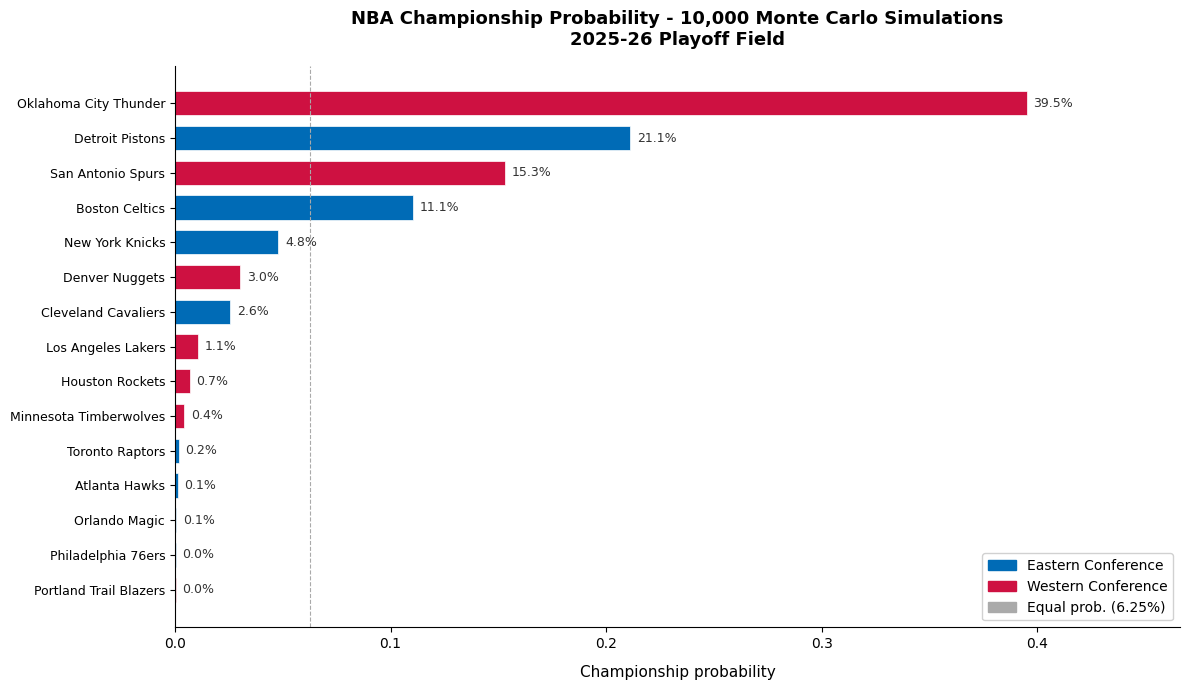

Saved: championship_probability_2026.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

colors = ["#006BB6" if c == "East" else "#CE1141"
          for c in df_results["conference"]]

bars = ax.barh(
    df_results["team"][::-1],
    df_results["probability"][::-1],
    color=colors[::-1],
    edgecolor="white",
    linewidth=0.5,
    height=0.7
)

for bar, prob in zip(bars, df_results["probability"][::-1]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
            f"{prob:.1%}", va="center", ha="left", fontsize=9, color="#333333")

ax.set_xlabel("Championship probability", fontsize=11, labelpad=10)
ax.set_title(
    f"NBA Championship Probability - {N_SIMS:,} Monte Carlo Simulations\n2025-26 Playoff Field",
    fontsize=13, pad=15, fontweight="bold"
)
ax.set_xlim(0, df_results["probability"].max() * 1.18)
ax.axvline(1 / 16, color="#aaaaaa", linestyle="--", linewidth=0.8, label="Equal probability (6.25%)")

east_patch = mpatches.Patch(color="#006BB6", label="Eastern Conference")
west_patch  = mpatches.Patch(color="#CE1141", label="Western Conference")
ax.legend(handles=[east_patch, west_patch,
                   mpatches.Patch(color="#aaaaaa", label="Equal prob. (6.25%)")],
          loc="lower right", framealpha=0.9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="y", labelsize=9)

plt.tight_layout()
plt.savefig("championship_probability_2026.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: championship_probability_2026.png")


## 6. Key first-round matchup: OKC vs Phoenix Suns

OKC enters as the #1 seed facing the #8 Suns. How often does each length outcome occur?


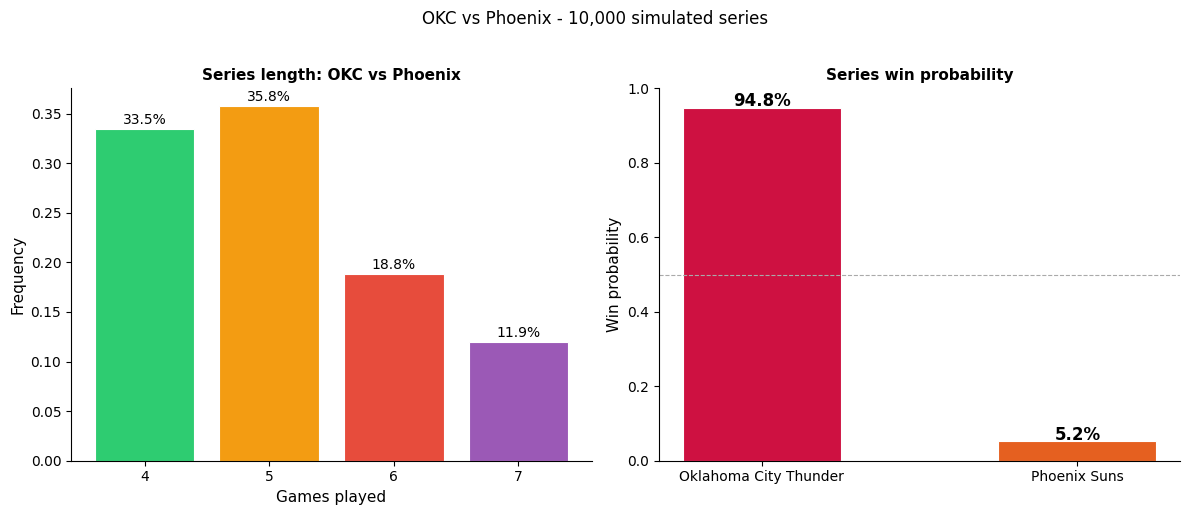

Saved: series_analysis_2026.png


In [ ]:
team_a, elo_a = "Oklahoma City Thunder", 1655
team_b, elo_b = "Phoenix Suns",          1445

series_lengths = []
series_winners = []

for _ in range(N_SIMS):
    w, g, _ = simulate_series(team_a, elo_a, team_b, elo_b)
    series_lengths.append(g)
    series_winners.append(w)

length_counts = Counter(series_lengths)
winner_counts = Counter(series_winners)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
lengths = [4, 5, 6, 7]
freqs   = [length_counts.get(l, 0) / N_SIMS for l in lengths]
ax.bar(lengths, freqs, color=["#2ecc71", "#f39c12", "#e74c3c", "#9b59b6"],
       edgecolor="white", linewidth=0.8)
for l, f in zip(lengths, freqs):
    ax.text(l, f + 0.005, f"{f:.1%}", ha="center", fontsize=10)
ax.set_xlabel("Games played", fontsize=11)
ax.set_ylabel("Frequency", fontsize=11)
ax.set_title(f"Series length: OKC vs Phoenix", fontsize=11, fontweight="bold")
ax.set_xticks(lengths)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax = axes[1]
teams  = [team_a, team_b]
probs  = [winner_counts[t] / N_SIMS for t in teams]
colors2 = ["#CE1141", "#E56020"]
bars2 = ax.bar(teams, probs, color=colors2, edgecolor="white", linewidth=0.8, width=0.5)
for bar, p in zip(bars2, probs):
    ax.text(bar.get_x() + bar.get_width() / 2, p + 0.005, f"{p:.1%}",
            ha="center", fontsize=12, fontweight="bold")
ax.set_ylabel("Win probability", fontsize=11)
ax.set_title("Series win probability", fontsize=11, fontweight="bold")
ax.set_ylim(0, 1)
ax.axhline(0.5, color="#aaaaaa", linestyle="--", linewidth=0.8)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.suptitle(f"OKC vs Phoenix - {N_SIMS:,} simulated series", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("series_analysis_2026.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: series_analysis_2026.png")


## 7. Sensitivity analysis: Wembanyama factor

The Spurs' title odds are heavily tied to Victor Wembanyama's performance. We sweep San Antonio's Elo from -150 to +150 to show how much their championship probability responds.


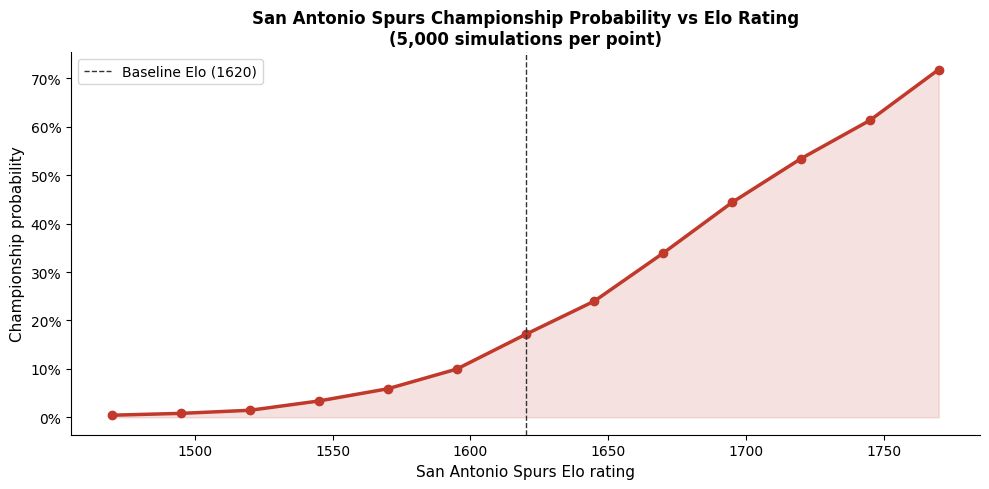

Saved: sensitivity_analysis_2026.png


In [ ]:
base_elo_sa = 1620
elo_offsets  = range(-150, 175, 25)
sa_probs = []

for offset in elo_offsets:
    df_mod = df_teams.copy()
    df_mod.loc[df_mod["team"] == "San Antonio Spurs", "elo"] = base_elo_sa + offset
    wins = sum(1 for _ in range(5_000) if simulate_bracket(df_mod) == "San Antonio Spurs")
    sa_probs.append(wins / 5_000)

fig, ax = plt.subplots(figsize=(10, 5))
elo_values = [base_elo_sa + o for o in elo_offsets]
ax.plot(elo_values, sa_probs, color="#C0392B", linewidth=2.5, marker="o", markersize=6)
ax.axvline(base_elo_sa, color="#333333", linestyle="--", linewidth=1,
           label=f"Baseline Elo ({base_elo_sa})")
ax.fill_between(elo_values, sa_probs, alpha=0.15, color="#C0392B")
ax.set_xlabel("San Antonio Spurs Elo rating", fontsize=11)
ax.set_ylabel("Championship probability", fontsize=11)
ax.set_title(
    "San Antonio Spurs Championship Probability vs Elo Rating\n(5,000 simulations per point)",
    fontsize=12, fontweight="bold"
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("sensitivity_analysis_2026.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sensitivity_analysis_2026.png")


## 8. Summary statistics


In [ ]:
print("=" * 57)
print(f"  NBA Championship Probabilities - {N_SIMS:,} simulations")
print(f"  2025-26 Playoff Field")
print("=" * 57)

for _, row in df_results.iterrows():
    bar = "X" * int(row.probability * 200)
    pct = f"{row.probability:.1%}"
    print(f"  {int(row['rank']):>2}. {row.team:<30} {pct:>6}  {bar}")

print()
okc_prob = df_results[df_results.team == "Oklahoma City Thunder"]["probability"].values[0]
sa_prob  = df_results[df_results.team == "San Antonio Spurs"]["probability"].values[0]
det_prob = df_results[df_results.team == "Detroit Pistons"]["probability"].values[0]

print(f"  OKC (defending champ, W1):    {okc_prob:.1%}")
print(f"  San Antonio (W2, Wembanyama): {sa_prob:.1%}")
print(f"  Detroit (E1, first since 2007): {det_prob:.1%}")
print()

east_prob = df_results[df_results.conference == "East"]["probability"].sum()
west_prob = df_results[df_results.conference == "West"]["probability"].sum()
print(f"  East teams combined: {east_prob:.1%}")
print(f"  West teams combined: {west_prob:.1%}")


  NBA Championship Probabilities - 10,000 simulations
  2025-26 Playoff Field
   1. Oklahoma City Thunder           39.5%  XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
   2. Detroit Pistons                 21.1%  XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
   3. San Antonio Spurs               15.3%  XXXXXXXXXXXXXXXXXXXXXXXXXXXXXX
   4. Boston Celtics                  11.1%  XXXXXXXXXXXXXXXXXXXXXX
   5. New York Knicks                  4.8%  XXXXXXXXX
   6. Denver Nuggets                   3.0%  XXXXXX
   7. Cleveland Cavaliers              2.6%  XXXXX
   8. Los Angeles Lakers               1.1%  XX
   9. Houston Rockets                  0.7%  X
  10. Minnesota Timberwolves           0.4%  
  11. Toronto Raptors                  0.2%  
  12. Atlanta Hawks                    0.1%  
  13. Orlando Magic                    0.1%  
  14. Philadelphia 76ers               0.0%  
  15. Portland Trail Blazers           0.0%  

  OKC (defending champ, W1):    39.


---
*Simulation built with NumPy. Elo ratings estimated from 2025-26 regular season results. Playoff bracket sourced from NBA.com and Wikipedia.*
